In [1]:
import json, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import defaultdict
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

MODEL_DIRS = {
    "anthropic_claude-sonnet-4-6": "Claude Sonnet 4.6",
    "google_gemini-3-flash-preview": "Gemini 3-Flash",
    "openai_gpt-5.2": "GPT-5.2",
}
MODEL_COLORS = {
    "Claude Sonnet 4.6": "#1f77b4",
    "Gemini 3-Flash":    "#ff7f0e",
    "GPT-5.2":           "#2ca02c",
}
MODEL_COLORS_DIR   = {k: MODEL_COLORS[v] for k, v in MODEL_DIRS.items()}
MODEL_LABEL_MAP_NL = {
    "anthropic_claude-sonnet-4-6": "Claude\nSonnet 4.6",
    "google_gemini-3-flash-preview": "Gemini\n3-Flash",
    "openai_gpt-5.2": "GPT-5.2",
}

P_CONDITIONS  = {"p09": (0.9, 1), "p05": (0.5, 5), "p02": (0.2, 8)}
P_LABEL_NAMES = {"p09": "Highly Parallel (p=0.9)", "p05": "Mixed (p=0.5)", "p02": "Mostly Serial (p=0.2)"}
P_SHORT_NAMES = {"p02": "p=0.2", "p05": "p=0.5", "p09": "p=0.9"}
P_COLORS      = {"p02": "#d7191c", "p05": "#fdae61", "p09": "#1a9641"}
P_LABELS      = ["p02", "p05", "p09"]  # canonical display order
N_VALUES      = [1, 2, 3, 4, 5]

def amdahl_speedup(p, n):
    return 1.0 / ((1.0 - p) + p / n)


# Preprocessing

In [2]:
# Load pre-processed parquet files
runs_df   = pd.read_parquet("data/runs.parquet")
events_df = pd.read_parquet("data/events.parquet")

dec_df = runs_df[runs_df["mode"] == "decentralized"].copy()
pre_df = runs_df[runs_df["mode"].isin(["preassign", "preassign_nolead"])].copy()

conflict_dec = dec_df.to_dict("records")
conflict_pre = pre_df.to_dict("records")

# EVENT DATA
_edit_evts = events_df[events_df["type"] == "edit_file"][["run_dir","path","round"]].dropna()
_first_w   = _edit_evts.groupby(["run_dir","path"])["round"].min().reset_index(name="first_round")
_edit_m    = _edit_evts.merge(_first_w, on=["run_dir","path"])
_rewrites  = (_edit_m[_edit_m["round"] > _edit_m["first_round"]]
              .groupby("run_dir").size().reset_index(name="rewrites"))

_rstart = (events_df[events_df["type"] == "round_start"][["run_dir","round","ts"]]
           .rename(columns={"ts": "round_ts"}))
_areplies = events_df[events_df["type"] == "agent_reply"][["run_dir","round","ts","agent"]].dropna(subset=["round"])
_lat_m = _areplies.merge(_rstart, on=["run_dir","round"])
_lat_m["latency"] = _lat_m["ts"] - _lat_m["round_ts"]
_lat_m = _lat_m[(_lat_m["latency"] > 0) & (_lat_m["latency"] < 180)]
_rnd_cnt = _lat_m.groupby(["run_dir","round"]).size().reset_index(name="n_agents")
_strag = (_lat_m.groupby(["run_dir","round"])["latency"]
          .agg(lat_max="max", lat_mean="mean").reset_index())
_strag = _strag.merge(_rnd_cnt, on=["run_dir","round"])
_strag = _strag[_strag["n_agents"] >= 2]
_strag["gap_s"] = _strag["lat_max"] - _strag["lat_mean"]
_run_meta = runs_df[["run_dir","n_teammates","p_label","model_dir","mode"]].copy()
strag_df = _strag.merge(_run_meta, on="run_dir")

_msg_cnt = (events_df[events_df["type"] == "agent_reply"]
            .groupby("run_dir").size().reset_index(name="messages"))

_ar_rnds = (events_df[events_df["type"] == "agent_reply"]
            .groupby(["run_dir","round"]).size().reset_index(name="n_replies"))
_ct_rnds = (events_df[events_df["type"] == "complete_task"]
            .groupby(["run_dir","round"]).size().reset_index(name="n_completes"))
_idle = (_ar_rnds.merge(_ct_rnds, on=["run_dir","round"], how="left")
         .fillna({"n_completes": 0}))
_idle = _idle[_idle["n_completes"] == 0]
_idle_cnt = _idle.groupby("run_dir").size().reset_index(name="idle")

ERROR_RCS = {1, 2, 3}
_tf = (events_df[(events_df["type"] == "run_tests") &
                 (events_df["returncode"].isin(ERROR_RCS))]
       .groupby("run_dir").size().reset_index(name="n_failures"))

_pre_run_dirs = set(pre_df[pre_df["success"] == True]["run_dir"])
_lat_pre = _lat_m[_lat_m["run_dir"].isin(_pre_run_dirs)].merge(_run_meta, on="run_dir")
_lat_pre["agent_type"] = _lat_pre["agent"].apply(lambda a: "Lead" if a == "Lead" else "Teammate")
df_lat = _lat_pre.rename(columns={"latency": "latency_s", "n_teammates": "n"}).copy()

def _model_summary(df_subset):
    task_types = sorted(df_subset["task_type"].unique())
    out = {}
    for lbl, (p_true, _) in P_CONDITIONS.items():
        out[lbl] = {}
        for n in N_VALUES:
            if n == 1:
                out[lbl][n] = {"mean": 1.0, "sem": 0.0}
                continue
            speedups, vars_ = [], []
            for tt in task_types:
                sub = df_subset[(df_subset["task_type"] == tt) & (df_subset["success"] == True)]
                base_runs = sub[(sub["p_label"] == lbl) & (sub["n_teammates"] == 1)]["wall_clock_seconds"].values
                n_runs    = sub[(sub["p_label"] == lbl) & (sub["n_teammates"] == n)]["wall_clock_seconds"].values
                if len(base_runs) == 0 or len(n_runs) == 0:
                    continue
                base_wc = float(np.mean(base_runs))
                n_wc    = float(np.mean(n_runs))
                sp = base_wc / n_wc
                speedups.append(sp)
                s2_b = float(np.var(base_runs, ddof=1)) if len(base_runs) > 1 else 0.0
                s2_n = float(np.var(n_runs,    ddof=1)) if len(n_runs)    > 1 else 0.0
                vars_.append(sp**2 * (s2_b / (len(base_runs) * base_wc**2) +
                                      s2_n / (len(n_runs)    * n_wc**2)))
            if not speedups:
                out[lbl][n] = None
                continue
            K = len(speedups)
            out[lbl][n] = {"mean": float(np.mean(speedups)),
                           "sem":  float(np.sqrt(sum(vars_)) / K)}
    return out

summaries     = {}  # preassign
summaries_dec = {}  # decentralized
for dir_name, label in MODEL_DIRS.items():
    sub_pre = pre_df[pre_df["model_dir"] == dir_name]
    sub_dec = dec_df[dec_df["model_dir"] == dir_name]
    if len(sub_pre): summaries[label]     = _model_summary(sub_pre)
    if len(sub_dec): summaries_dec[label] = _model_summary(sub_dec)

all_n = sorted(strag_df["n_teammates"].unique())

def _strag_series(df, p_label, n_vals):
    sub = df[df["p_label"] == p_label]
    xs, ms, ss = [], [], []
    for n in n_vals:
        g = sub[sub["n_teammates"] == n]["gap_s"].dropna()
        if len(g) < 2:
            continue
        xs.append(n)
        ms.append(g.mean())
        ss.append(g.std(ddof=1) / np.sqrt(len(g)))
    return np.array(xs), np.array(ms), np.array(ss)


# Amdahl Speedup Analyses

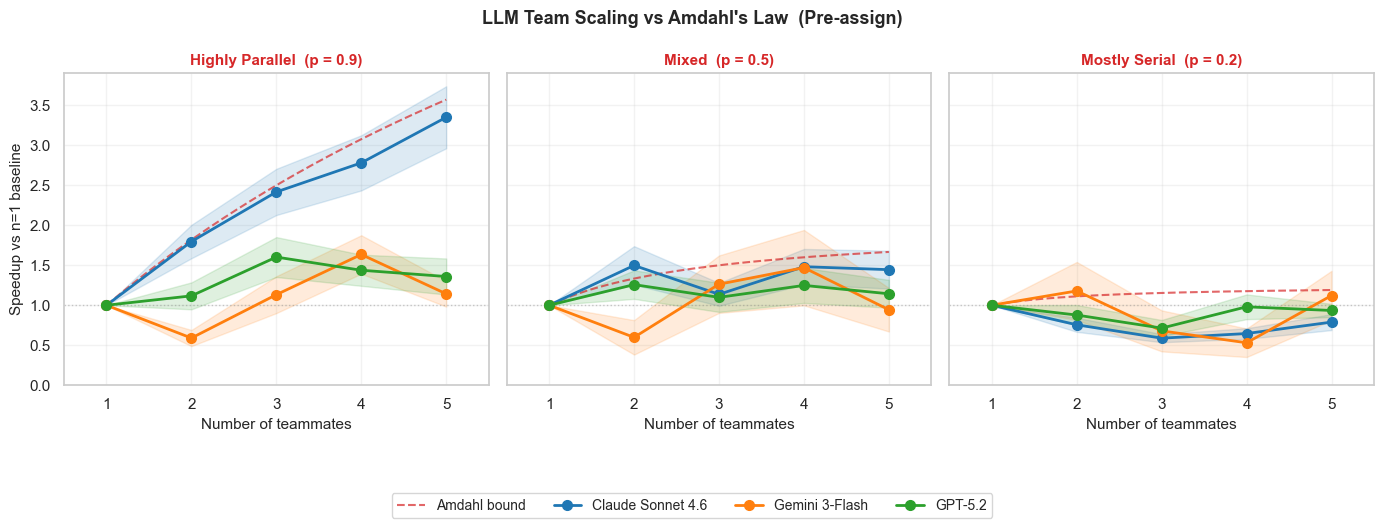

In [3]:
P_SUBPLOT_CONFIG = [
    ("p09", 0.9, "Highly Parallel  (p = 0.9)", "#d62728"),
    ("p05", 0.5, "Mixed  (p = 0.5)",            "#d62728"),
    ("p02", 0.2, "Mostly Serial  (p = 0.2)",    "#d62728"),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
n_smooth = np.linspace(1, max(N_VALUES), 300)

for ax, (p_label, p_true, title, p_color) in zip(axes, P_SUBPLOT_CONFIG):
    ax.plot(n_smooth, [amdahl_speedup(p_true, n) for n in n_smooth],
            color=p_color, linestyle="--", linewidth=1.5, alpha=0.7, label="Amdahl bound")
    ax.axhline(1.0, color="gray", linestyle=":", linewidth=1, alpha=0.4)
    for model_label, color in MODEL_COLORS.items():
        if model_label not in summaries:
            continue
        rows = [(n, summaries[model_label][p_label][n])
                for n in N_VALUES if summaries[model_label][p_label].get(n)]
        if not rows:
            continue
        xs    = np.array([n        for n, r in rows])
        means = np.array([r["mean"] for _, r in rows])
        sems  = np.array([r["sem"]  for _, r in rows])
        ax.fill_between(xs, means - sems, means + sems, color=color, alpha=0.15)
        ax.plot(xs, means, "o-", color=color, linewidth=2, markersize=7, label=model_label)
    ax.set_title(title, fontsize=11, fontweight="bold", color=p_color)
    ax.set_xlabel("Number of teammates", fontsize=11)
    ax.set_xticks(N_VALUES)
    ax.set_xlim(0.5, max(N_VALUES) + 0.5)
    ax.set_ylim(bottom=0.0)
    ax.grid(alpha=0.25)

axes[0].set_ylabel("Speedup vs n=1 baseline", fontsize=11)
seen, handles, labels_leg = set(), [], []
for ax in axes:
    for h, l in zip(*ax.get_legend_handles_labels()):
        if l not in seen:
            seen.add(l); handles.append(h); labels_leg.append(l)
fig.legend(handles, labels_leg, loc="lower center", ncol=len(seen),
           fontsize=10, bbox_to_anchor=(0.5, -0.05))
fig.suptitle("LLM Team Scaling vs Amdahl's Law  (Pre-assign)", fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()


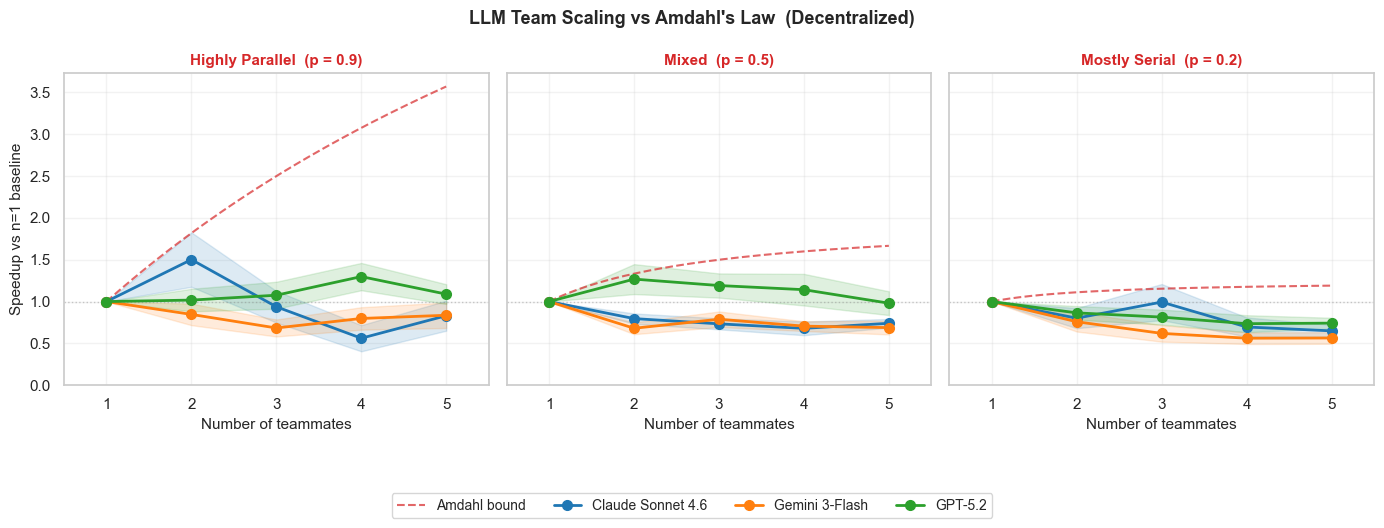

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
n_smooth = np.linspace(1, max(N_VALUES), 300)

for ax, (p_label, p_true, title, p_color) in zip(axes, P_SUBPLOT_CONFIG):
    ax.plot(n_smooth, [amdahl_speedup(p_true, n) for n in n_smooth],
            color=p_color, linestyle="--", linewidth=1.5, alpha=0.7, label="Amdahl bound")
    ax.axhline(1.0, color="gray", linestyle=":", linewidth=1, alpha=0.4)
    for model_label, color in MODEL_COLORS.items():
        if model_label not in summaries_dec:
            continue
        rows = [(n, summaries_dec[model_label][p_label][n])
                for n in N_VALUES if summaries_dec[model_label][p_label].get(n)]
        if not rows:
            continue
        xs    = np.array([n        for n, r in rows])
        means = np.array([r["mean"] for _, r in rows])
        sems  = np.array([r["sem"]  for _, r in rows])
        ax.fill_between(xs, means - sems, means + sems, color=color, alpha=0.15)
        ax.plot(xs, means, "o-", color=color, linewidth=2, markersize=7, label=model_label)
    ax.set_title(title, fontsize=11, fontweight="bold", color=p_color)
    ax.set_xlabel("Number of teammates", fontsize=11)
    ax.set_xticks(N_VALUES)
    ax.set_xlim(0.5, max(N_VALUES) + 0.5)
    ax.set_ylim(bottom=0.0)
    ax.grid(alpha=0.25)

axes[0].set_ylabel("Speedup vs n=1 baseline", fontsize=11)
seen, handles, labels_leg = set(), [], []
for ax in axes:
    for h, l in zip(*ax.get_legend_handles_labels()):
        if l not in seen:
            seen.add(l); handles.append(h); labels_leg.append(l)
fig.legend(handles, labels_leg, loc="lower center", ncol=len(seen),
           fontsize=10, bbox_to_anchor=(0.5, -0.05))
fig.suptitle("LLM Team Scaling vs Amdahl's Law  (Decentralized)", fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()


# Consistency conflicts

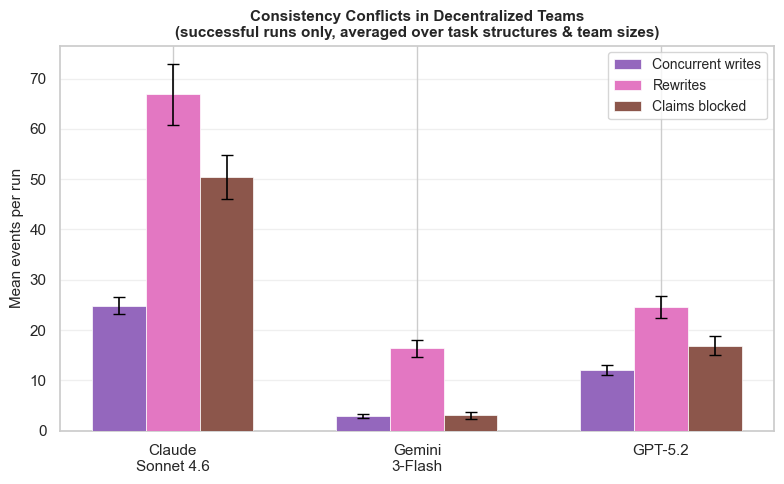

In [5]:
# Conflict comparison
METRICS = [
    ("concurrent_writes", "#9467bd", "Concurrent writes"),
    ("rewrites",          "#e377c2", "Rewrites"),
    ("claims_blocked",    "#8c564b", "Claims blocked"),
]

dec_ok = dec_df[dec_df["success"] == True].copy()
dec_ok = dec_ok.merge(_rewrites, on="run_dir", how="left").fillna({"rewrites": 0})

all_model_dirs = sorted(dec_ok["model_dir"].unique())
model_labels   = [MODEL_LABEL_MAP_NL.get(m, m) for m in all_model_dirs]
bar_width = 0.22
x = np.arange(len(all_model_dirs))
offsets = np.linspace(-(len(METRICS)-1)/2, (len(METRICS)-1)/2, len(METRICS)) * bar_width

fig, ax = plt.subplots(figsize=(8, 5))
for i, (metric, color, label) in enumerate(METRICS):
    means, sems = [], []
    for model_dir in all_model_dirs:
        vals = dec_ok[dec_ok["model_dir"] == model_dir][metric].values.astype(float)
        means.append(vals.mean() if len(vals) > 0 else np.nan)
        sems.append(vals.std(ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else 0.0)
    ax.bar(x + offsets[i], means, width=bar_width, color=color, label=label,
           edgecolor="white", linewidth=0.5, zorder=3)
    ax.errorbar(x + offsets[i], means, yerr=sems, fmt="none", color="black",
                capsize=4, linewidth=1.2, zorder=4)

ax.set_ylabel("Mean events per run", fontsize=11)
ax.set_xticks(x); ax.set_xticklabels(model_labels, fontsize=11)
ax.set_ylim(bottom=0); ax.grid(axis="y", alpha=0.3, zorder=0)
ax.legend(fontsize=10)
ax.set_title("Consistency Conflicts in Decentralized Teams\n"
             "(successful runs only, averaged over task structures & team sizes)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()


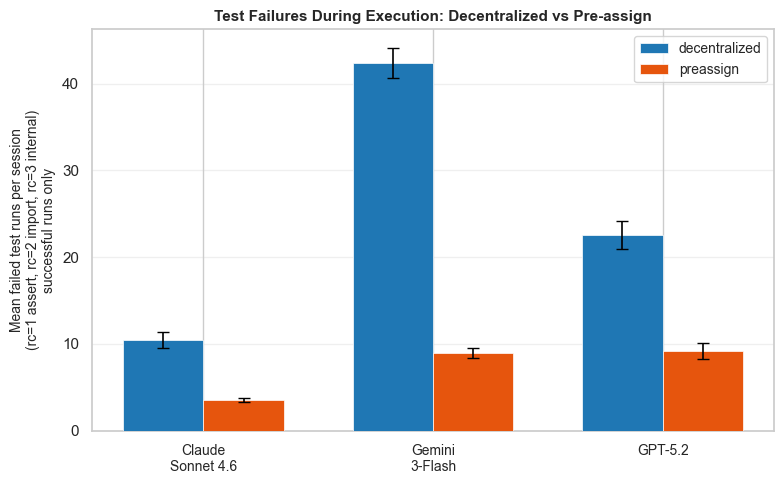

In [6]:
# Test failures
dec_ok_runs = dec_df[dec_df["success"] == True][["run_dir","model_dir"]].copy()
pre_ok_runs = pre_df[pre_df["success"] == True][["run_dir","model_dir"]].copy()
dec_ok_runs = dec_ok_runs.merge(_tf, on="run_dir", how="left").fillna({"n_failures": 0})
pre_ok_runs = pre_ok_runs.merge(_tf, on="run_dir", how="left").fillna({"n_failures": 0})

COND_STYLES = [
    ("decentralized", dec_ok_runs, "#1f77b4"),
    ("preassign",     pre_ok_runs, "#e6550d"),
]
all_model_dirs = sorted(runs_df["model_dir"].unique())
model_labels   = [MODEL_LABEL_MAP_NL.get(m, m) for m in all_model_dirs]
bar_width = 0.35
x = np.arange(len(all_model_dirs))
offsets = [-bar_width / 2, bar_width / 2]

fig, ax = plt.subplots(figsize=(8, 5))
for i, (cond_label, df, color) in enumerate(COND_STYLES):
    means, sems = [], []
    for model_dir in all_model_dirs:
        vals = df[df["model_dir"] == model_dir]["n_failures"].values.astype(float)
        means.append(vals.mean() if len(vals) > 0 else np.nan)
        sems.append(vals.std(ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else 0.0)
    ax.bar(x + offsets[i], means, width=bar_width, color=color, label=cond_label,
           edgecolor="white", linewidth=0.5, zorder=3)
    ax.errorbar(x + offsets[i], means, yerr=sems, fmt="none", color="black",
                capsize=4, linewidth=1.2, zorder=4)

ax.set_xticks(x); ax.set_xticklabels(model_labels, fontsize=10)
ax.set_ylim(bottom=0)
ax.set_ylabel("Mean failed test runs per session\n(rc=1 assert, rc=2 import, rc=3 internal)\nsuccessful runs only", fontsize=10)
ax.legend(fontsize=10); ax.grid(axis="y", alpha=0.3, zorder=0)
ax.set_title("Test Failures During Execution: Decentralized vs Pre-assign", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()


# Straggler gap

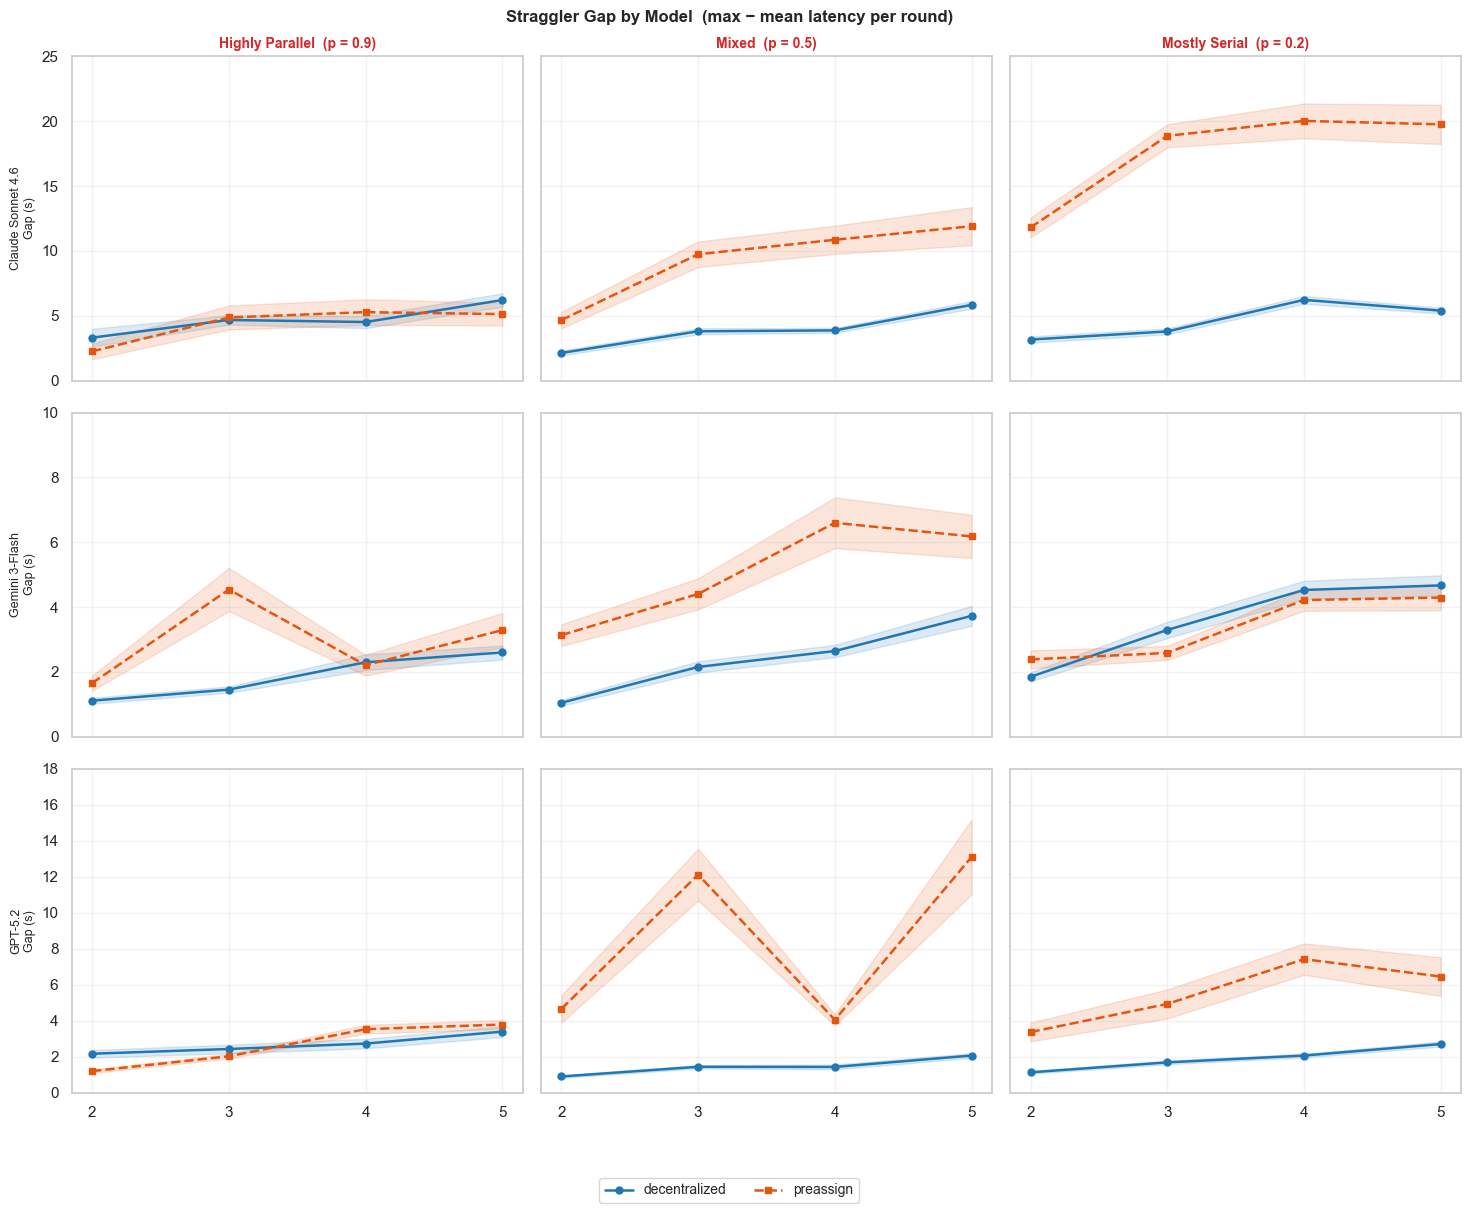

In [ ]:
# Straggler gap
YLIM_BY_MODEL = {
    "anthropic_claude-sonnet-4-6":   25,
    "google_gemini-3-flash-preview": 10,
    "openai_gpt-5.2":                18,
}
COND_PLOT = [
    ("decentralized",    "decentralized",    "-",  "o", "#1f77b4"),
    ("preassign",        "preassign_nolead", "--", "s", "#e6550d"),
]

n_models = len(MODEL_DIRS)
fig, axes = plt.subplots(n_models, 3, figsize=(15, 4 * n_models), sharey="row", sharex=True)
fig.suptitle("Straggler Gap by Model  (max − mean latency per round)", fontsize=12, fontweight="bold")

for row_idx, (dir_name, model_label) in enumerate(MODEL_DIRS.items()):
    sub_m = strag_df[strag_df["model_dir"] == dir_name]
    ylim = YLIM_BY_MODEL.get(dir_name, 20)
    for col_idx, (p_label, p_true, title, p_color) in enumerate(P_SUBPLOT_CONFIG):
        ax = axes[row_idx][col_idx]
        for cond_label, mode_val, ls, mk, color in COND_PLOT:
            xs, ms, ss = _strag_series(sub_m[sub_m["mode"] == mode_val], p_label, all_n)
            if len(xs) == 0: continue
            ax.fill_between(xs, ms - ss, ms + ss, color=color, alpha=0.15)
            ax.plot(xs, ms, linestyle=ls, marker=mk, color=color,
                    linewidth=1.8, markersize=5, label=cond_label)
        if row_idx == 0:
            ax.set_title(title, fontsize=10, fontweight="bold", color=p_color)
        ax.set_ylim(0, ylim); ax.set_xticks(all_n); ax.grid(alpha=0.25)
        if col_idx == 0:
            ax.set_ylabel(f"{model_label}\nGap (s)", fontsize=9)

handles, labels_ = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels_, loc="lower center", ncol=2,
           fontsize=10, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()


In [8]:
# Cost–Speedup tradeoff
def _build_cs_df(df_subset):
    recs = df_subset[df_subset["success"] == True].copy()
    recs["total_tok"] = recs["total_input_tokens"] + recs["total_output_tokens"]
    recs = recs[recs["total_tok"] > 0]
    if recs.empty: return None
    grp = (recs.groupby(["task_type","p_label","model_dir","n_teammates"])[["wall_clock_seconds","total_tok"]]
               .mean().reset_index())
    base = (grp[grp["n_teammates"] == 1]
            .rename(columns={"wall_clock_seconds": "base_wc", "total_tok": "base_tok"})
            [["task_type","p_label","model_dir","base_wc","base_tok"]])
    grp = grp.merge(base, on=["task_type","p_label","model_dir"])
    grp["speedup"]    = grp["base_wc"]   / grp["wall_clock_seconds"]
    grp["token_mult"] = grp["total_tok"] / grp["base_tok"]
    grp["efficiency"] = grp["speedup"]   / grp["token_mult"]
    return grp

def _color_efficiency(col):
    return ["background-color: #d4edda" if float(v) >= 0.8
            else "background-color: #fff3cd" if float(v) >= 0.4
            else "background-color: #f8d7da" for v in col]

def _print_cs_tables_by_model(grp_means, condition_label):
    for model in sorted(grp_means["model_dir"].unique()):
        m_df = grp_means[grp_means["model_dir"] == model]
        print(f"\n{'═'*60}\n  {condition_label}  |  {model}\n{'═'*60}")
        for p_label, p_name in P_LABEL_NAMES.items():
            sub = m_df[m_df["p_label"] == p_label]
            rows = []
            for n in [1,2,3,4,5]:
                g = sub[sub["n_teammates"] == n]
                if g.empty: continue
                rows.append({"n teammates": n,
                             "Speedup":    f"{g['speedup'].mean():.2f}×",
                             "Token cost": f"{g['token_mult'].mean():.2f}×",
                             "Efficiency": f"{g['efficiency'].mean():.2f}"})
            if not rows: continue
            print(f"\n{'─'*48}\n  {p_name}\n{'─'*48}")
            display(pd.DataFrame(rows).set_index("n teammates").style
                    .set_table_styles([{"selector": "th,td", "props": [("text-align","center")]}])
                    .apply(_color_efficiency, subset=["Efficiency"]))

CS_CONDITIONS = [("Pre-assign", pre_df), ("Decentralized", dec_df)]
for cond_label, df_sub in CS_CONDITIONS:
    grp = _build_cs_df(df_sub)
    if grp is None:
        print(f"No token data for {cond_label}."); continue
    _print_cs_tables_by_model(grp, cond_label)
print("\nEfficiency = Speedup ÷ Token cost  (1.0 = perfect; <1 = diminishing returns)")
print("Green ≥ 0.8 · Yellow ≥ 0.4 · Red < 0.4")



════════════════════════════════════════════════════════════
  Pre-assign  |  anthropic_claude-sonnet-4-6
════════════════════════════════════════════════════════════

────────────────────────────────────────────────
  Highly Parallel (p=0.9)
────────────────────────────────────────────────


,Speedup,Token cost,Efficiency
n teammates,,,
1,1.00×,1.00×,1.00
2,1.80×,1.57×,4.17
3,2.42×,1.06×,5.91
4,2.78×,1.16×,5.81
5,3.35×,1.33×,7.07



────────────────────────────────────────────────
  Mixed (p=0.5)
────────────────────────────────────────────────


,Speedup,Token cost,Efficiency
n teammates,,,
1,1.00×,1.00×,1.00
2,1.50×,0.97×,2.21
3,1.14×,1.46×,0.80
4,1.48×,1.36×,1.42
5,1.45×,1.69×,1.18



────────────────────────────────────────────────
  Mostly Serial (p=0.2)
────────────────────────────────────────────────


...


────────────────────────────────────────────────
  Mixed (p=0.5)
────────────────────────────────────────────────


,Speedup,Token cost,Efficiency
n teammates,,,
1,1.00×,1.00×,1.00
2,1.27×,1.29×,1.27
3,1.19×,1.61×,0.78
4,1.14×,2.21×,0.83
5,0.98×,2.39×,0.47



────────────────────────────────────────────────
  Mostly Serial (p=0.2)
────────────────────────────────────────────────


,Speedup,Token cost,Efficiency
n teammates,,,
1,1.00×,1.00×,1.00
2,0.86×,1.58×,0.57
3,0.81×,2.32×,0.37
4,0.74×,3.30×,0.27
5,0.74×,3.33×,0.27



Efficiency = Speedup ÷ Token cost  (1.0 = perfect; <1 = diminishing returns)
Green ≥ 0.8 · Yellow ≥ 0.4 · Red < 0.4


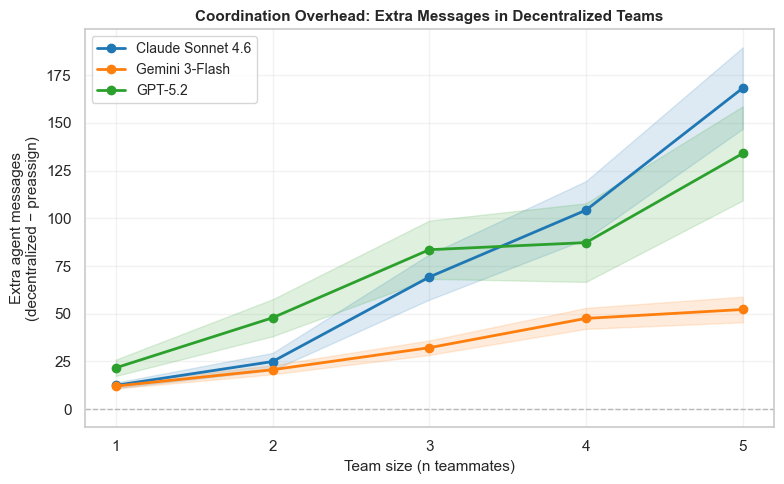

In [9]:
# Extra messages
dec_msgs = dec_df.merge(_msg_cnt, on="run_dir", how="left").fillna({"messages": 0})
pre_msgs = pre_df.merge(_msg_cnt, on="run_dir", how="left").fillna({"messages": 0})

df_msgs = pd.concat([
    dec_msgs[["n_teammates","model_dir","messages"]].assign(condition="decentralized"),
    pre_msgs[["n_teammates","model_dir","messages"]].assign(condition="preassign"),
])

all_n_m      = sorted(df_msgs["n_teammates"].unique())
all_models_m = sorted(df_msgs["model_dir"].unique())

fig, ax = plt.subplots(figsize=(8, 5))
ax.axhline(0, color="gray", linewidth=1, linestyle="--", alpha=0.5)

for model_dir in all_models_m:
    color  = MODEL_COLORS_DIR.get(model_dir, "black")
    mlabel = MODEL_DIRS.get(model_dir, model_dir)
    xs, diffs, sems = [], [], []
    for n in all_n_m:
        dec_v = df_msgs[(df_msgs["model_dir"] == model_dir) &
                        (df_msgs["condition"] == "decentralized") &
                        (df_msgs["n_teammates"] == n)]["messages"].values
        pre_v = df_msgs[(df_msgs["model_dir"] == model_dir) &
                        (df_msgs["condition"] == "preassign") &
                        (df_msgs["n_teammates"] == n)]["messages"].values
        if len(dec_v) == 0 or len(pre_v) == 0: continue
        diff = dec_v.mean() - pre_v.mean()
        sem  = np.sqrt((dec_v.std(ddof=1)**2 / len(dec_v) if len(dec_v) > 1 else 0) +
                       (pre_v.std(ddof=1)**2 / len(pre_v) if len(pre_v) > 1 else 0))
        xs.append(n); diffs.append(diff); sems.append(sem)
    if xs:
        ax.fill_between(xs, np.array(diffs) - np.array(sems),
                        np.array(diffs) + np.array(sems), color=color, alpha=0.15)
        ax.plot(xs, diffs, "o-", color=color, linewidth=2, markersize=6, label=mlabel)

ax.set_xlabel("Team size (n teammates)", fontsize=11)
ax.set_ylabel("Extra agent messages\n(decentralized − preassign)", fontsize=11)
ax.set_xticks(all_n_m); ax.legend(fontsize=10); ax.grid(alpha=0.25)
ax.set_title("Coordination Overhead: Extra Messages in Decentralized Teams", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()


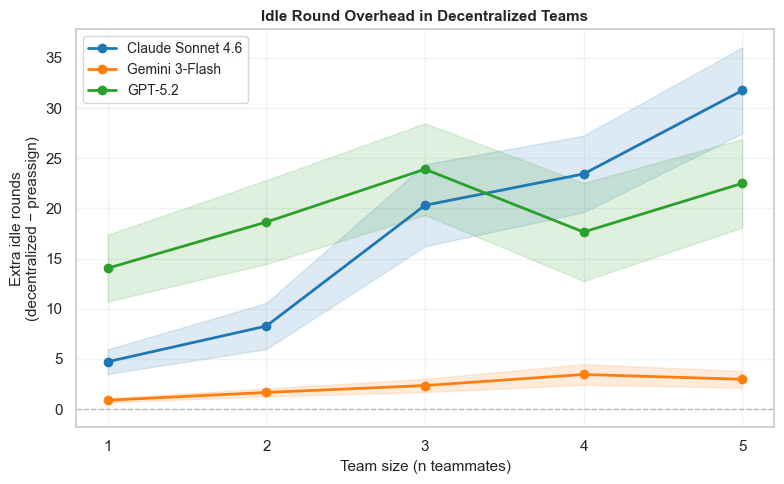

In [10]:
# Extra idle rounds
dec_idle = dec_df.merge(_idle_cnt, on="run_dir", how="left").fillna({"idle": 0})
pre_idle = pre_df.merge(_idle_cnt, on="run_dir", how="left").fillna({"idle": 0})

df_idle = pd.concat([
    dec_idle[["n_teammates","model_dir","idle"]].assign(condition="decentralized"),
    pre_idle[["n_teammates","model_dir","idle"]].assign(condition="preassign"),
])

all_n_i      = sorted(df_idle["n_teammates"].unique())
all_models_i = sorted(df_idle["model_dir"].unique())

fig, ax = plt.subplots(figsize=(8, 5))
ax.axhline(0, color="gray", linewidth=1, linestyle="--", alpha=0.5)

for model_dir in all_models_i:
    color  = MODEL_COLORS_DIR.get(model_dir, "black")
    mlabel = MODEL_DIRS.get(model_dir, model_dir)
    xs, diffs, sems = [], [], []
    for n in all_n_i:
        dec_v = df_idle[(df_idle["model_dir"] == model_dir) &
                        (df_idle["condition"] == "decentralized") &
                        (df_idle["n_teammates"] == n)]["idle"].values
        pre_v = df_idle[(df_idle["model_dir"] == model_dir) &
                        (df_idle["condition"] == "preassign") &
                        (df_idle["n_teammates"] == n)]["idle"].values
        if len(dec_v) == 0 or len(pre_v) == 0: continue
        diff = dec_v.mean() - pre_v.mean()
        sem  = np.sqrt((dec_v.std(ddof=1)**2 / len(dec_v) if len(dec_v) > 1 else 0) +
                       (pre_v.std(ddof=1)**2 / len(pre_v) if len(pre_v) > 1 else 0))
        xs.append(n); diffs.append(diff); sems.append(sem)
    if xs:
        ax.fill_between(xs, np.array(diffs) - np.array(sems),
                        np.array(diffs) + np.array(sems), color=color, alpha=0.15)
        ax.plot(xs, diffs, "o-", color=color, linewidth=2, markersize=6, label=mlabel)

ax.set_xlabel("Team size (n teammates)", fontsize=11)
ax.set_ylabel("Extra idle rounds\n(decentralized − preassign)", fontsize=11)
ax.set_xticks(all_n_i); ax.legend(fontsize=10); ax.grid(alpha=0.25)
ax.set_title("Idle Round Overhead in Decentralized Teams", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()


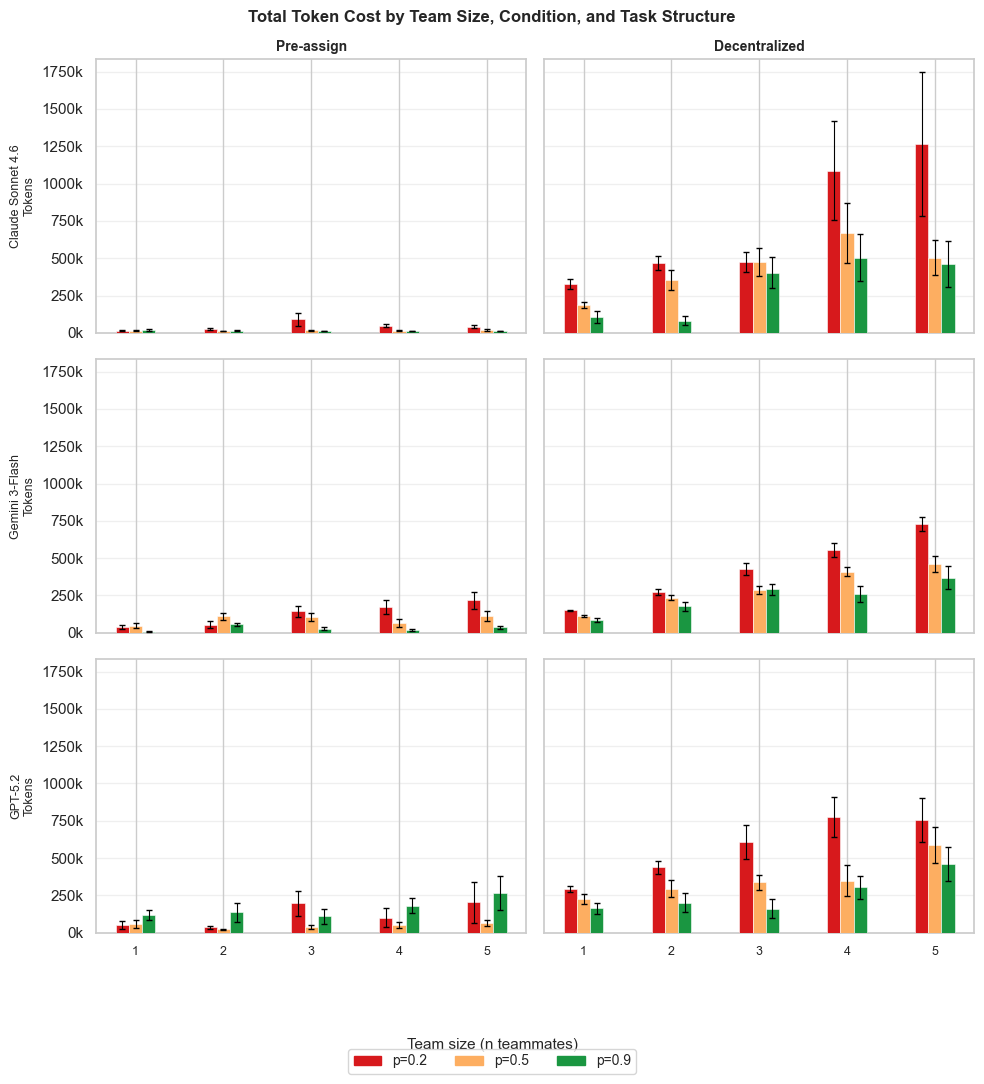

In [ ]:
# Token Cost
CONDITIONS = [("Pre-assign", pre_df), ("Decentralized", dec_df)]

tok_recs = []
for cond_label, df_sub in CONDITIONS:
    for _, r in df_sub[df_sub["success"] == True].iterrows():
        total_tok = r["total_input_tokens"] + r["total_output_tokens"]
        if not total_tok: continue
        tok_recs.append({"condition": cond_label, "n": int(r["n_teammates"]),
                         "p_label": r["p_label"], "model_dir": r["model_dir"],
                         "task_type": r["task_type"], "total_tok": total_tok})
df_tok = pd.DataFrame(tok_recs)

models  = sorted(df_tok["model_dir"].unique())
bar_w   = 0.15
offsets = np.linspace(-(len(P_LABELS)-1)/2, (len(P_LABELS)-1)/2, len(P_LABELS)) * bar_w
xs      = np.arange(len(N_VALUES))

n_rows, n_cols = len(models), len(CONDITIONS)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 3.5*n_rows), sharex=True, sharey=True)
if n_rows == 1: axes = axes[np.newaxis, :]
fig.subplots_adjust(hspace=0.35, wspace=0.08)

for row, model in enumerate(models):
    for col, (cond_label, _) in enumerate(CONDITIONS):
        ax = axes[row, col]
        sub = df_tok[(df_tok["model_dir"] == model) & (df_tok["condition"] == cond_label)]
        for j, pl in enumerate(P_LABELS):
            for i, n in enumerate(N_VALUES):
                g = sub[(sub["p_label"] == pl) & (sub["n"] == n)]["total_tok"]
                if g.empty: continue
                x_c = xs[i] + offsets[j]
                sem = g.sem() if len(g) > 1 else 0.0
                ax.bar(x_c, g.mean(), width=bar_w, color=P_COLORS[pl],
                       label=P_SHORT_NAMES[pl] if i == 0 else "", edgecolor="white",
                       linewidth=0.4, zorder=3)
                ax.errorbar(x_c, g.mean(), yerr=sem, fmt="none", color="black",
                            capsize=2, linewidth=0.8, zorder=4)
        if row == 0:
            ax.set_title(cond_label, fontsize=10, fontweight="bold")
        ax.set_xticks(xs); ax.set_xticklabels(N_VALUES, fontsize=9)
        if col == 0:
            ax.set_ylabel(f"{MODEL_DIRS[model]}\nTokens", fontsize=9)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e3:.0f}k"))
        ax.grid(axis="y", alpha=0.3, zorder=0)

handles = [plt.Rectangle((0,0),1,1, color=P_COLORS[pl]) for pl in P_LABELS]
fig.legend(handles, [P_SHORT_NAMES[pl] for pl in P_LABELS], loc="lower center",
           ncol=len(P_LABELS), fontsize=10, bbox_to_anchor=(0.5, -0.04))
fig.suptitle("Total Token Cost by Team Size, Condition, and Task Structure",
             fontsize=12, fontweight="bold")
fig.text(0.5, -0.01, "Team size (n teammates)", ha="center", fontsize=11)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()
